# Geometric Corrections

Not every scintillation photon produced by the alpha can reach the SiPMs: part of them are absorbed by the
**teflon (PTFE) walls** of the cell and part by the **alpha source** itself (the Am-241 disc and its holder).
This notebook uses the Geant4/nexus simulations in `data/MarcFactors/*_correct` to measure, for each gas and pressure,

* $\varepsilon_{\rm teflon}$: fraction of the created photons that are **not** absorbed by the teflon,
* $\varepsilon_{\rm source}$: fraction of the created photons that are **not** absorbed by the source,
* $\varepsilon_{\rm tot}$: fraction of the created photons that **survive both**, i.e. that can reach the SiPMs.

$\varepsilon_{\rm tot}$ is the correction applied in `EfficiencyVSPressure.ipynb`, where the absolute yield $N_\gamma$
(Saito et al.) is turned into the number of photons that can be detected, $N_\gamma \cdot \varepsilon_{\rm tot}$,
before dividing the measured p.e. by it to obtain the LCE.

## The simulation

One file per gas (Ar, Xe) and pressure (1.0 to 8.5 bar), each with 20000 events. Settings (stored in `MC/configuration`
and printed below): 5.486 MeV alphas (the main Am-241 line) generated isotropically from the source region
(`INSIDE_CIGAR`, $\cos\theta \in [-1, 1]$, $\phi \in [0, 2\pi]$), TPB coating and 1 mm Y11 fibers.

The files only keep the photon summary (`MC/photon_summary`), one row per event:

| column | meaning |
|---|---|
| `photons_created` | scintillation photons created in the gas by the alpha |
| `teflon_hits` | of those, photons that end up absorbed in the teflon |
| `source_hits` | of those, photons that end up absorbed in the source |

The number of photons per event (~100 for a full-energy alpha) is far below the real yield (~$10^5$, see
`EfficiencyVSPressure.ipynb`), so the scintillation yield in the simulation is scaled down. This does not matter here:
only the **fractions** hits / photons are used, and those do not depend on how many photons are generated,
only on where they are generated and on the geometry and optical properties of the cell.

### Why the corrections depend on gas and pressure

The range of a 5.5 MeV alpha is inversely proportional to the gas density: a few cm at 1 bar, shrinking as the
pressure goes up, and shorter in Xe than in Ar at the same pressure (Xe is denser). The scintillation light is
emitted along the track, so the pressure changes **where** the light is produced:

* **Low pressure**: long tracks that reach far from the source, often up to the teflon walls. The light is
  produced spread over the cell and close to the walls, so the teflon absorbs more and the source less.
* **High pressure**: short tracks, so all the light is produced in a small region next to the source. The source
  covers a large solid angle as seen from there and absorbs more; the teflon absorbs less.

The two effects go in opposite directions, but the source term grows faster, so the overall
$\varepsilon_{\rm tot}$ decreases with pressure.

### What the data look like

Each event is one alpha, and the photon spectrum (`photons_created`) has three populations. The table gives the
number of events (out of 20000) in each range of created photons:

| | 0 | 1–9 | 10–69 | 70–79 | $\ge$ 80 | full-energy peak: mean, std, $\sqrt{\rm mean}$ |
|---|---|---|---|---|---|---|
| Ar 2.5 bar | 11873 | 1554 | 300 | 92 | 6181 | 109.0, 10.9, 10.4 |
| Xe 8.5 bar | 9157 | 3774 | 785 | 95 | 6189 | 109.0, 10.7, 10.4 |
| Xe 1.0 bar | 12113 | 1349 | 703 | 560 | 5275 | 104.9, 12.4, 10.2 |
| Ar 1.0 bar | 12636 | 904 | 4959 | 343 | 1158 | 103.0, 13.2, 10.1 |

* **No light (0 photons, 45–63% of the events).** The alphas are generated isotropically at the source, so
  roughly half of them go into the source itself and never reach the gas. These are the bright bin at (0, 0) in
  the maps.
* **Partial energy (tail, 1–70 photons).** The alpha leaves only part of its 5.5 MeV in the gas: it comes out at a
  grazing angle and loses energy in the source material first, or it hits a surface before stopping. In the maps
  this is the band that goes from the origin to the peak: the hits grow in proportion to the photons, with a slope
  equal to the absorbed fraction. The light of these events is produced right next to the source, so
  the source absorbs a larger fraction of it than for full-energy alphas (Xe 8.5 bar: 48% for events with 20–70 photons
  against 42% in the peak; Ar 2.5 bar: 30% against 12%).
* **Full energy (peak at ~105–110 photons).** The alpha stops in the gas and deposits all its energy. From 1.5 bar
  up, the width of the peak is $\sqrt{\rm mean}$: the number of photons fluctuates only with Poisson statistics.

**Ar at 1 bar is different.** A 5.5 MeV alpha travels several cm in 1 bar of argon, more than the size of the
cell, so most alphas reach the walls before they stop. The bulk of the events is at 30–60 photons, and only ~6% of them
form a full-energy peak, which is also wider than Poisson (13.2 instead of 10.1) because it still contains alphas that
lost a bit of energy at the walls. Xe at 1 bar is in between.

**Why only the peak is used.** In the real measurement the LCE is computed from the position of the full-energy
peak (the rightmost crystal ball in `ChargeSpectrum.ipynb`), and $N_\gamma$ (Saito et al.) is the yield of an alpha
that deposits all its energy. The correction must then be the absorption **for those events**, which is why the fit
only uses events with `photons_created >= photon_threshold`. Including the tail would mix in events with a
different geometry (more source absorption) that are not in the measured peak.

In [30]:
import glob
import importlib
import os
import re
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap, LogNorm, to_rgb
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit

current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'
sys.path.append(os.path.abspath(os.path.join(current_dir, '../functions')))
import cigar as cig

In [31]:
font_size = 20
# Configure matplotlib to use Computer Modern fonts and mathtext
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size

GAS_NAMES = {'Ar': 'Argon', 'Xe': 'Xenon'}

# Same colors as FingerPlot4CHs.ipynb (cute_colors)
DATA_COLOR = 'green'
FIT_COLOR  = 'red'


def alpha_cmap(color, alpha_min=0.02, alpha_max=1.0, gamma=1.5, darken=0.45, n=256):
    """Single-color colormap: the lowest counts are almost transparent and the highest fully opaque.

    gamma > 1 keeps the low counts faint for longer, and the color also gets darker towards the top
    (by the fraction `darken`), so the gradient is more pronounced."""
    t = np.linspace(0, 1, n)
    rgba = np.ones((n, 4))
    rgba[:, :3] = np.outer(1 - darken * t, to_rgb(color))
    rgba[:, 3] = alpha_min + (alpha_max - alpha_min) * t**gamma
    return ListedColormap(rgba)


DATA_CMAP = alpha_cmap(DATA_COLOR, alpha_min=0.08, gamma=1, darken=0)   # softer, linear fade
FIT_CMAP  = alpha_cmap(FIT_COLOR)                                         # stronger fade, darker peak

# 1, 2, 3 sigma contours: all in the fit color, told apart by the line style
SIGMA_STYLES = {1: '-', 2: '--', 3: ':'}

In [32]:
data_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/data/MarcFactors'

# Map every available file to (gas, pressure)
files = {}
for path in glob.glob(os.path.join(data_dir, '*_correct', 'Cigar_*_alpha_*.next.h5')):
    m = re.search(r'Cigar_([\d.]+)_alpha_(\w+)\.next\.h5', os.path.basename(path))
    files[(m.group(2), float(m.group(1)))] = path

for gas in sorted({g for g, _ in files}):
    print(f"{gas}: {sorted(p for g, p in files if g == gas)} bar")

Ar: [1.0, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5] bar
Xe: [1.0, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5] bar


## Choose gas and pressure

`photon_threshold` separates the full-energy alphas from the tail: only events with at least that many created photons
enter the fit (black dash-dotted line in the data + fit maps).

**Why 80 photons.** From 1.5 bar up there is a clear valley at 60–80 photons between the tail and the peak (the 70–79
column in the table above has fewer than 100 events), and the peak is at ~109 with $\sigma \approx 10.5$, so
80 photons is ~3$\sigma$ below the peak: it keeps more than 99% of the full-energy alphas and leaves out almost all the
tail. The result does not depend on the exact value: moving the threshold between 70 and 90 photons changes
$\varepsilon_{\rm tot}$ (computed from the summed hits and photons of the selected events) by less than 0.001 from 2.5 bar up. At 1 bar there is no clean valley and the change is
about $\pm 0.01$, which should be taken as a systematic error at that pressure.

`n_bins_photons` is the number of bins along the photons axis of the maps.

In [33]:
gas      = 'Xe'   # 'Ar' or 'Xe'
pressure = 8.5    # [bar]

photon_threshold = 80   # only events with photons_created >= threshold enter the fit
n_bins_photons   = 50

write_eps = False   # True: save eps_tot of all pressures of `gas` into cigar.GetEpsTot (used by EfficiencyVSPressure)

In [34]:
def load_photon_summary(path):
    with h5py.File(path, 'r') as f:
        df = pd.DataFrame(f['MC/photon_summary'][:])
        config = {k.decode().strip(): v.decode().strip() for k, v in f['MC/configuration'][:]}
    return df, config

df, config = load_photon_summary(files[(gas, pressure)])
label = f"{GAS_NAMES.get(gas, gas)}, {pressure} bar"

print(f"File: {files[(gas, pressure)]}")
print(f"Gas: {config['/Geometry/Cigar/gas']}, pressure: {config['/Geometry/Cigar/pressure']}, "
      f"coating: {config['/Geometry/Cigar/coating']}, fiber: {config['/Geometry/Cigar/fiber_type']}")
print(f"Events: {len(df)}, with photons: {(df.photons_created > 0).sum()}")
df.describe()

File: /home/marian/CIGAR_ANALYSIS/CIGAR/data/MarcFactors/Xe_correct/Cigar_8.5_alpha_Xe.next.h5
Gas: Xe, pressure: 8.5 bar, coating: TPB, fiber: Y11
Events: 20000, with photons: 10843


,event_id,photons_created,teflon_hits,source_hits
count,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,35.789050,4.275600,15.202100
std,5773.647028,50.090064,6.556004,21.439392
min,0.000000,0.000000,0.000000,0.000000
25%,4999.750000,0.000000,0.000000,0.000000
50%,9999.500000,1.000000,0.000000,0.000000
75%,14999.250000,100.000000,9.000000,39.000000
max,19999.000000,148.000000,35.000000,83.000000


## 2D Gaussian fit

### What a 2D Gaussian represents

For each full-energy alpha there are two numbers: $x$ = photons created and $y$ = how many of them are absorbed (by
the source or by the teflon). Both fluctuate from event to event, and they do it together:

* $x$ follows Poisson statistics around ~105–110 photons (the width of the peak is $\sqrt{\rm mean}$, see above).
  A Poisson distribution with such a large mean is very close to a Gaussian.
* For a given $x$, each photon is absorbed or not with some probability $p$, so $y$ is binomial around $p\,x$, also
  close to a Gaussian. On top of that, $p$ changes a bit from event to event with the direction of the alpha.
* If $x$ is high, $y$ tends to be high too, because there are more photons to absorb. So $x$ and $y$ are
  **correlated**.

Two quantities that are each Gaussian and correlated with each other follow a **2D Gaussian**: a single peak whose
lines of equal probability are ellipses, centred on the average event $(\mu_x, \mu_y)$ and tilted by the correlation.
This is why it is the natural model for the peak of the maps. The fit gives exactly the number we need,
$\mu_y/\mu_x$ (the average fraction absorbed), together with the uncertainties and their correlation. The ellipses
also give a visual check that the model really describes the data.

It is not meant to describe the tail or the (0, 0) events, which are excluded by the threshold.

### The model

$$G(x, y) = A \exp\left[-\frac{1}{2(1-\rho^2)}\left(\frac{(x-\mu_x)^2}{\sigma_x^2} - \frac{2\rho(x-\mu_x)(y-\mu_y)}{\sigma_x\sigma_y} + \frac{(y-\mu_y)^2}{\sigma_y^2}\right)\right]$$

$$G(x, y) = A \exp\left[-\frac{1}{2(1-\rho^2)}\left(\frac{(x-\mu_x)^2}{\sigma_x^2} - \frac{2\rho(x-\mu_x)(y-\mu_y)}{\sigma_x\sigma_y} + \frac{(y-\mu_y)^2}{\sigma_y^2}\right)\right]$$

* $A$: height of the peak [counts per bin],
* $\mu_x, \sigma_x$: mean and spread of the photons created by a full-energy alpha,
* $\mu_y, \sigma_y$: mean and spread of the number of photons absorbed,
* $\rho = \mathrm{cov}(x, y) / (\sigma_x \sigma_y) \in (-1, 1)$: correlation coefficient between $x$ and $y$.
  It tilts the ellipses: $\rho \approx 0$ means the number of hits does not depend on how many photons were created
  (axis-aligned ellipses), $\rho > 0$ means events with more photons also have more hits.

### Physics of $\rho$

 If every photon had the same probability $p$ of being absorbed, the hits would be a binomial
sample of the photons, $\langle y | x \rangle = p\,x$, and $\rho = p\,\sigma_x/\sigma_y$. The fitted $\rho$ is lower than
that because $p$ changes from event to event with the direction of the alpha: a track pointing to the walls loses more
light in the teflon, one running along the source loses more in the source. The source hits are dominated by this
geometric variation, so their $\rho$ is close to 0 (in Ar at 1 bar, 0.08 instead of the 0.29 expected for a constant $p$).

### How the fit is done (`fit_gaussian_2d`)

**Why fit instead of just averaging?** Above the threshold one could simply take the mean of $x$ and $y$. The two agree within
~0.01 (e.g. Xe 8.5 bar: 0.458 both; Ar 2.5 bar: 0.573 fit, 0.566 average). The fit is used because it follows the shape of
the peak and is less sensitive to the tail events that leak above the threshold, which have more source absorption
(at 1 bar, where this leak is largest, the fit gives 0.707 and the average 0.691). It also gives the
covariance of $\mu_x$ and $\mu_y$ needed for the error, and the ellipses used to check it by eye.

Steps:

1. The selected events ($x \ge$ `photon_threshold`) are binned in the same 2D histogram used for the plots.
2. The starting values are the moments of those events: means, standard deviations and correlation coefficient,
   with $A$ = highest bin.
3. `scipy.optimize.curve_fit` does a least-squares fit of $G$ to the bin contents, only for bins with
   $x \ge$ `photon_threshold`, weighting each bin by its Poisson error $\sqrt{N}$ (1 for empty bins, so they still
   pull the model down where there are no events). $\sigma$'s are kept positive and $|\rho| < 0.99$.
4. It returns the parameters and their covariance matrix, used later for the errors on the corrections.

In [35]:
def gaussian_2d(xy, A, mux, muy, sx, sy, rho):
    x, y = xy
    dx, dy = (x - mux) / sx, (y - muy) / sy
    z = (dx**2 - 2 * rho * dx * dy + dy**2) / (1 - rho**2)
    return A * np.exp(-0.5 * z)


def fit_gaussian_2d(x, y, x_edges, y_edges, threshold):
    """Fit a correlated 2D Gaussian to the histogram of the events with x >= threshold."""
    sel = x >= threshold
    H, _, _ = np.histogram2d(x[sel], y[sel], bins=[x_edges, y_edges])

    xc = 0.5 * (x_edges[1:] + x_edges[:-1])
    yc = 0.5 * (y_edges[1:] + y_edges[:-1])
    X, Y = np.meshgrid(xc, yc, indexing='ij')

    # Initial guess from the moments of the selected events
    p0 = [H.max(), x[sel].mean(), y[sel].mean(), x[sel].std(), y[sel].std(),
          np.corrcoef(x[sel], y[sel])[0, 1]]

    # Only fit the bins above threshold, Poisson errors (min 1)
    mask = (X >= threshold).ravel()
    sigma = np.sqrt(np.maximum(H.ravel()[mask], 1))
    popt, pcov = curve_fit(gaussian_2d, (X.ravel()[mask], Y.ravel()[mask]), H.ravel()[mask],
                           p0=p0, sigma=sigma, absolute_sigma=True,
                           bounds=([0, -np.inf, -np.inf, 1e-3, 1e-3, -0.99],
                                   [np.inf, np.inf, np.inf, np.inf, np.inf, 0.99]))
    return popt, pcov

## How the 2D maps are made

For each type of hit (source, teflon), `plot_hits_vs_photons` makes **two separate figures** with the same bins:

1. **2D Gaussian fit**: the fitted $G(x, y)$ evaluated at the bin centres, i.e. what the histogram would look like if
   the full-energy events followed the Gaussian exactly. The colour scale covers three orders of magnitude below the peak.
2. **Data + fit**: the simulated events (`np.histogram2d` of **all** events, including the ones below the threshold,
   which are not fitted) with the fitted ellipses and the threshold on top.
   * Contours where the fitted Gaussian falls to $e^{-n^2/2}$ of its peak, for $n = 1, 2, 3$ (red solid, dashed,
     dotted; the circle is the fitted mean $(\mu_x, \mu_y)$). These are the $n\sigma$ curves of the correlated
     Gaussian. In 2D they contain 39%, 86% and 99% of the events (not the 68/95/99.7% of 1D).
   * Black dash-dotted line: `photon_threshold`. Only the events to its right are fitted.

Details:

* **Binning**: `n_bins_photons` bins from 0 to the maximum number of photons on the $x$ axis; on the $y$ axis one bin
  per integer number of hits (centred on the integer), made wider only if there are more than 80 possible values.
* **Colours**: the colors of `FingerPlot4CHs.ipynb`, green for the data and red for the fit. Each map uses a single
  color whose transparency follows the counts: the lowest counts are almost transparent and the highest fully opaque
  (the fit map also gets darker towards the peak, to make the gradient stronger).
  The scale is logarithmic because the counts go from 1 to ~$10^4$ (the (0, 0) bin), so a linear scale would only show
  that one bin. Empty bins are left white.

**How to read the data + fit map:** the bright bin at (0, 0) is the alphas that went into the source; the band from the origin
is the partial-energy tail, with a slope equal to the absorbed fraction; the blob on the right is the full-energy
peak. A good fit has the ellipses centred on the blob and following its tilt. The ellipses do not need to describe anything to the
left of the threshold.

In [36]:
def hist_edges(x, y, n_bins_photons=50):
    x_edges = np.linspace(0, x.max() + 1, n_bins_photons + 1)
    y_edges = np.arange(-0.5, y.max() + 1.5, max(1, int(np.ceil((y.max() + 1) / 80))))
    return x_edges, y_edges


def plot_hits_vs_photons(df, column, ylabel, label, threshold, n_bins_photons=50):
    x = df['photons_created'].to_numpy()
    y = df[column].to_numpy()

    x_edges, y_edges = hist_edges(x, y, n_bins_photons)

    H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    popt, pcov = fit_gaussian_2d(x, y, x_edges, y_edges, threshold)
    perr = np.sqrt(np.diag(pcov))

    xc = 0.5 * (x_edges[1:] + x_edges[:-1])
    yc = 0.5 * (y_edges[1:] + y_edges[:-1])
    X, Y = np.meshgrid(xc, yc, indexing='ij')
    model = gaussian_2d((X, Y), *popt)

    title = f'{ylabel} vs photons created: {label}'

    # 1) Fit
    fig, ax = plt.subplots(1, 1, figsize=(12, 9), dpi=150, constrained_layout=True)
    pc = ax.pcolormesh(x_edges, y_edges, model.T, cmap=FIT_CMAP,
                       norm=LogNorm(vmin=max(model.min(), 1e-3 * popt[0]), vmax=model.max()))
    ax.set_title(f'{title}\n2D Gaussian fit')
    fig.colorbar(pc, ax=ax).set_label('Fitted counts', rotation=270, va='bottom')
    ax.set_xlabel('Photons created')
    ax.set_ylabel(ylabel)
    plt.show()

    # 2) Data + fit contours: n-sigma ellipse is where the exponent equals n^2
    fig, ax = plt.subplots(1, 1, figsize=(12, 9), dpi=150, constrained_layout=True)
    H_plot = np.where(H > 0, H, np.nan).T   # empty bins stay white
    pc = ax.pcolormesh(x_edges, y_edges, H_plot, norm=LogNorm(vmin=1, vmax=H.max()), cmap=DATA_CMAP)

    xf = np.linspace(x_edges[0], x_edges[-1], 300)
    yf = np.linspace(y_edges[0], y_edges[-1], 300)
    XF, YF = np.meshgrid(xf, yf, indexing='ij')
    ZF = gaussian_2d((XF, YF), *popt) / popt[0]
    for n, ls in SIGMA_STYLES.items():
        ax.contour(XF, YF, ZF, levels=[np.exp(-0.5 * n**2)], colors=FIT_COLOR, linestyles=ls, linewidths=3)
    ax.plot(popt[1], popt[2], 'o', color=FIT_COLOR, markerfacecolor='white', markersize=10, mew=2.5, zorder=5)
    ax.axvline(threshold, color='k', ls='-.', lw=2)

    handles = [Line2D([], [], color=FIT_COLOR, ls=ls, lw=3, label=rf'Fit ${n}\sigma$') for n, ls in SIGMA_STYLES.items()]
    handles.append(Line2D([], [], color='k', ls='-.', lw=2, label=f'Fit threshold ({threshold} photons)'))
    ax.legend(handles=handles, loc='upper left', framealpha=0.5, fontsize=font_size)
    ax.set_title(f'{title}\nData + fit')
    fig.colorbar(pc, ax=ax).set_label('Counts', rotation=270, va='bottom')
    ax.set_xlabel('Photons created')
    ax.set_ylabel(ylabel)
    plt.show()

    names = ['A', 'mu_photons', f'mu_{column}', 'sigma_photons', f'sigma_{column}', 'rho']
    for n, v, e in zip(names, popt, perr):
        print(f"  {n:>20s} = {v:10.4f} ± {e:.4f}")
    return popt, pcov

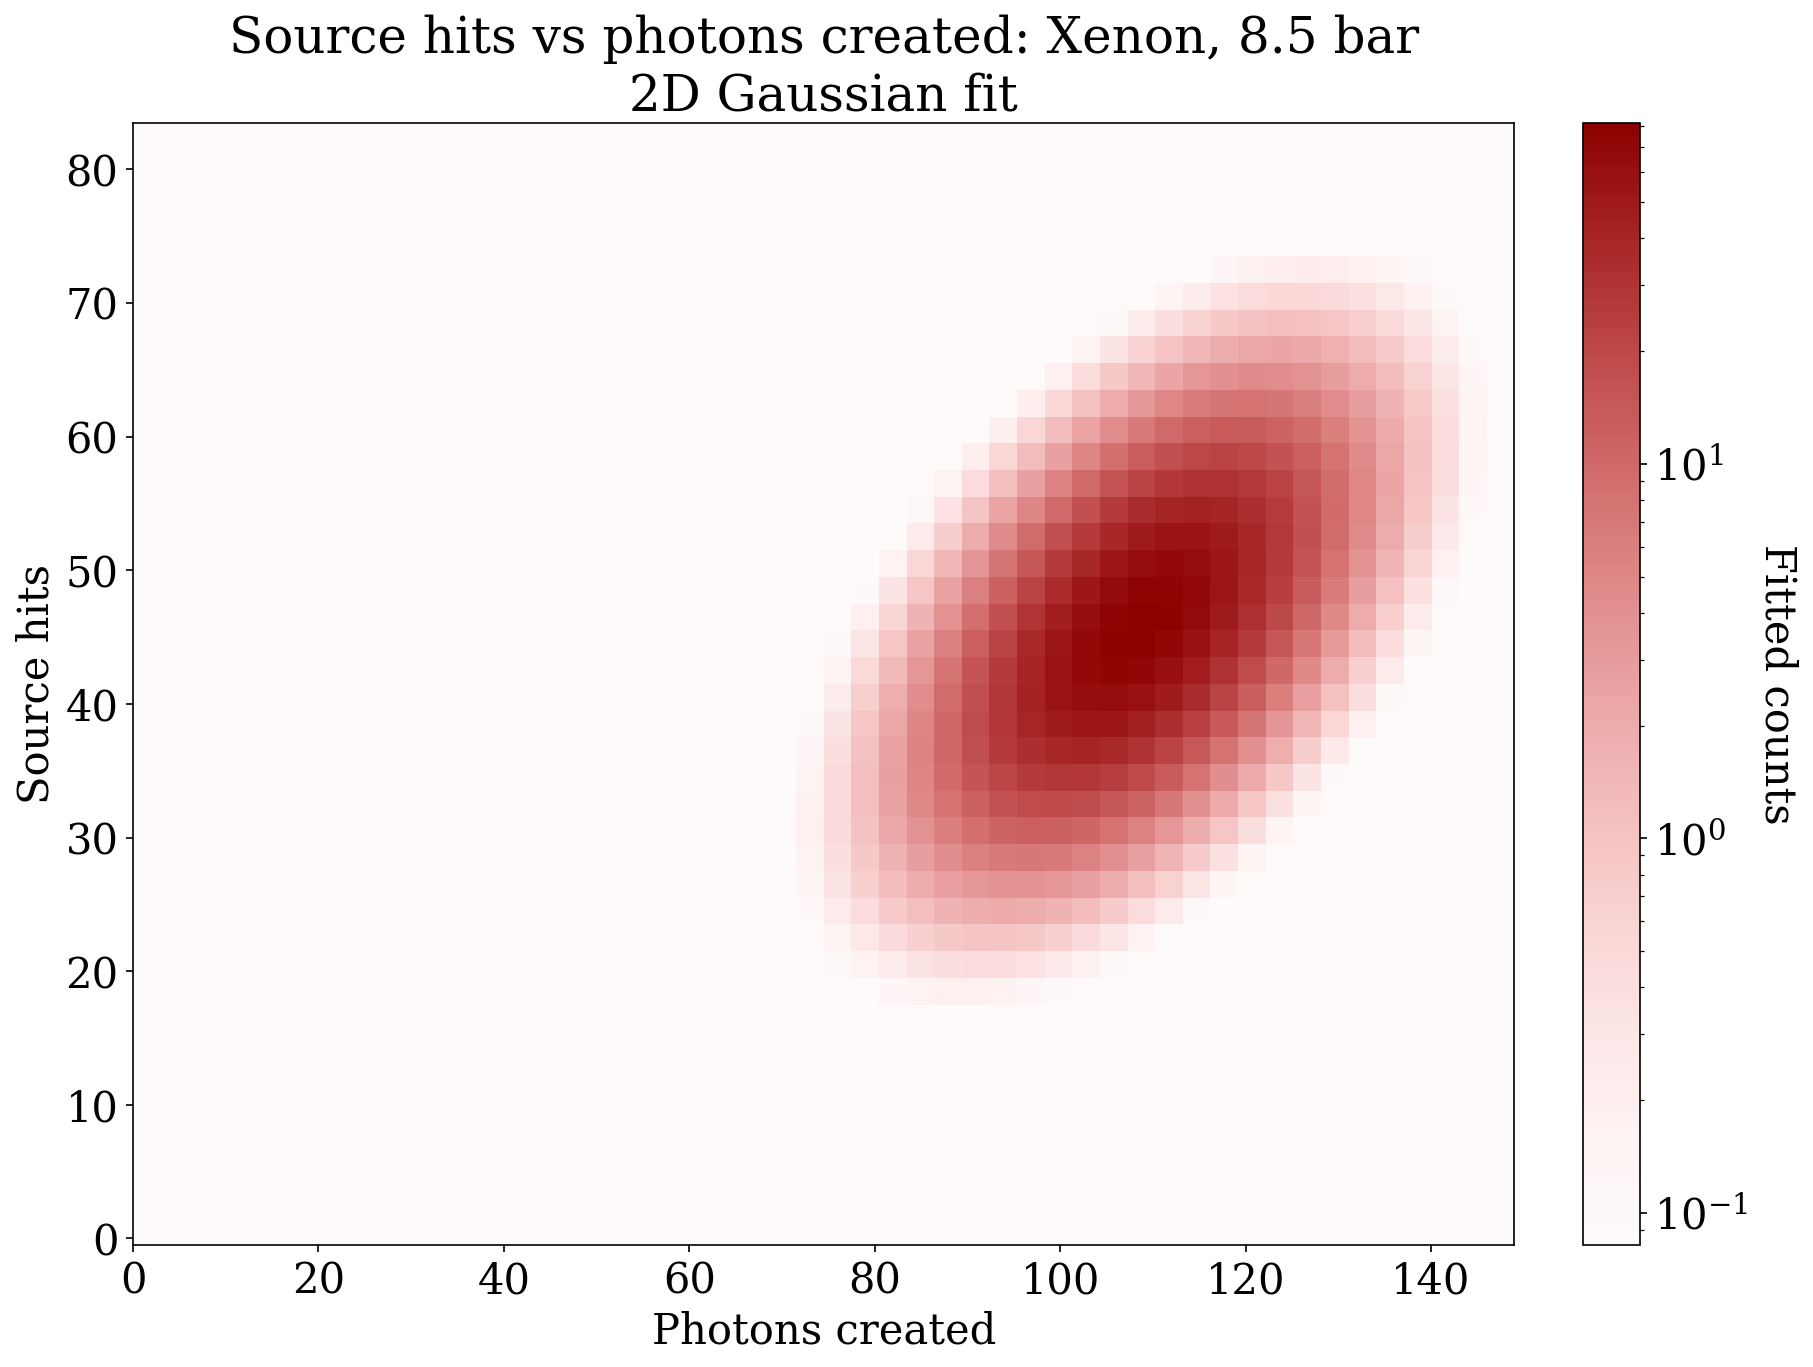

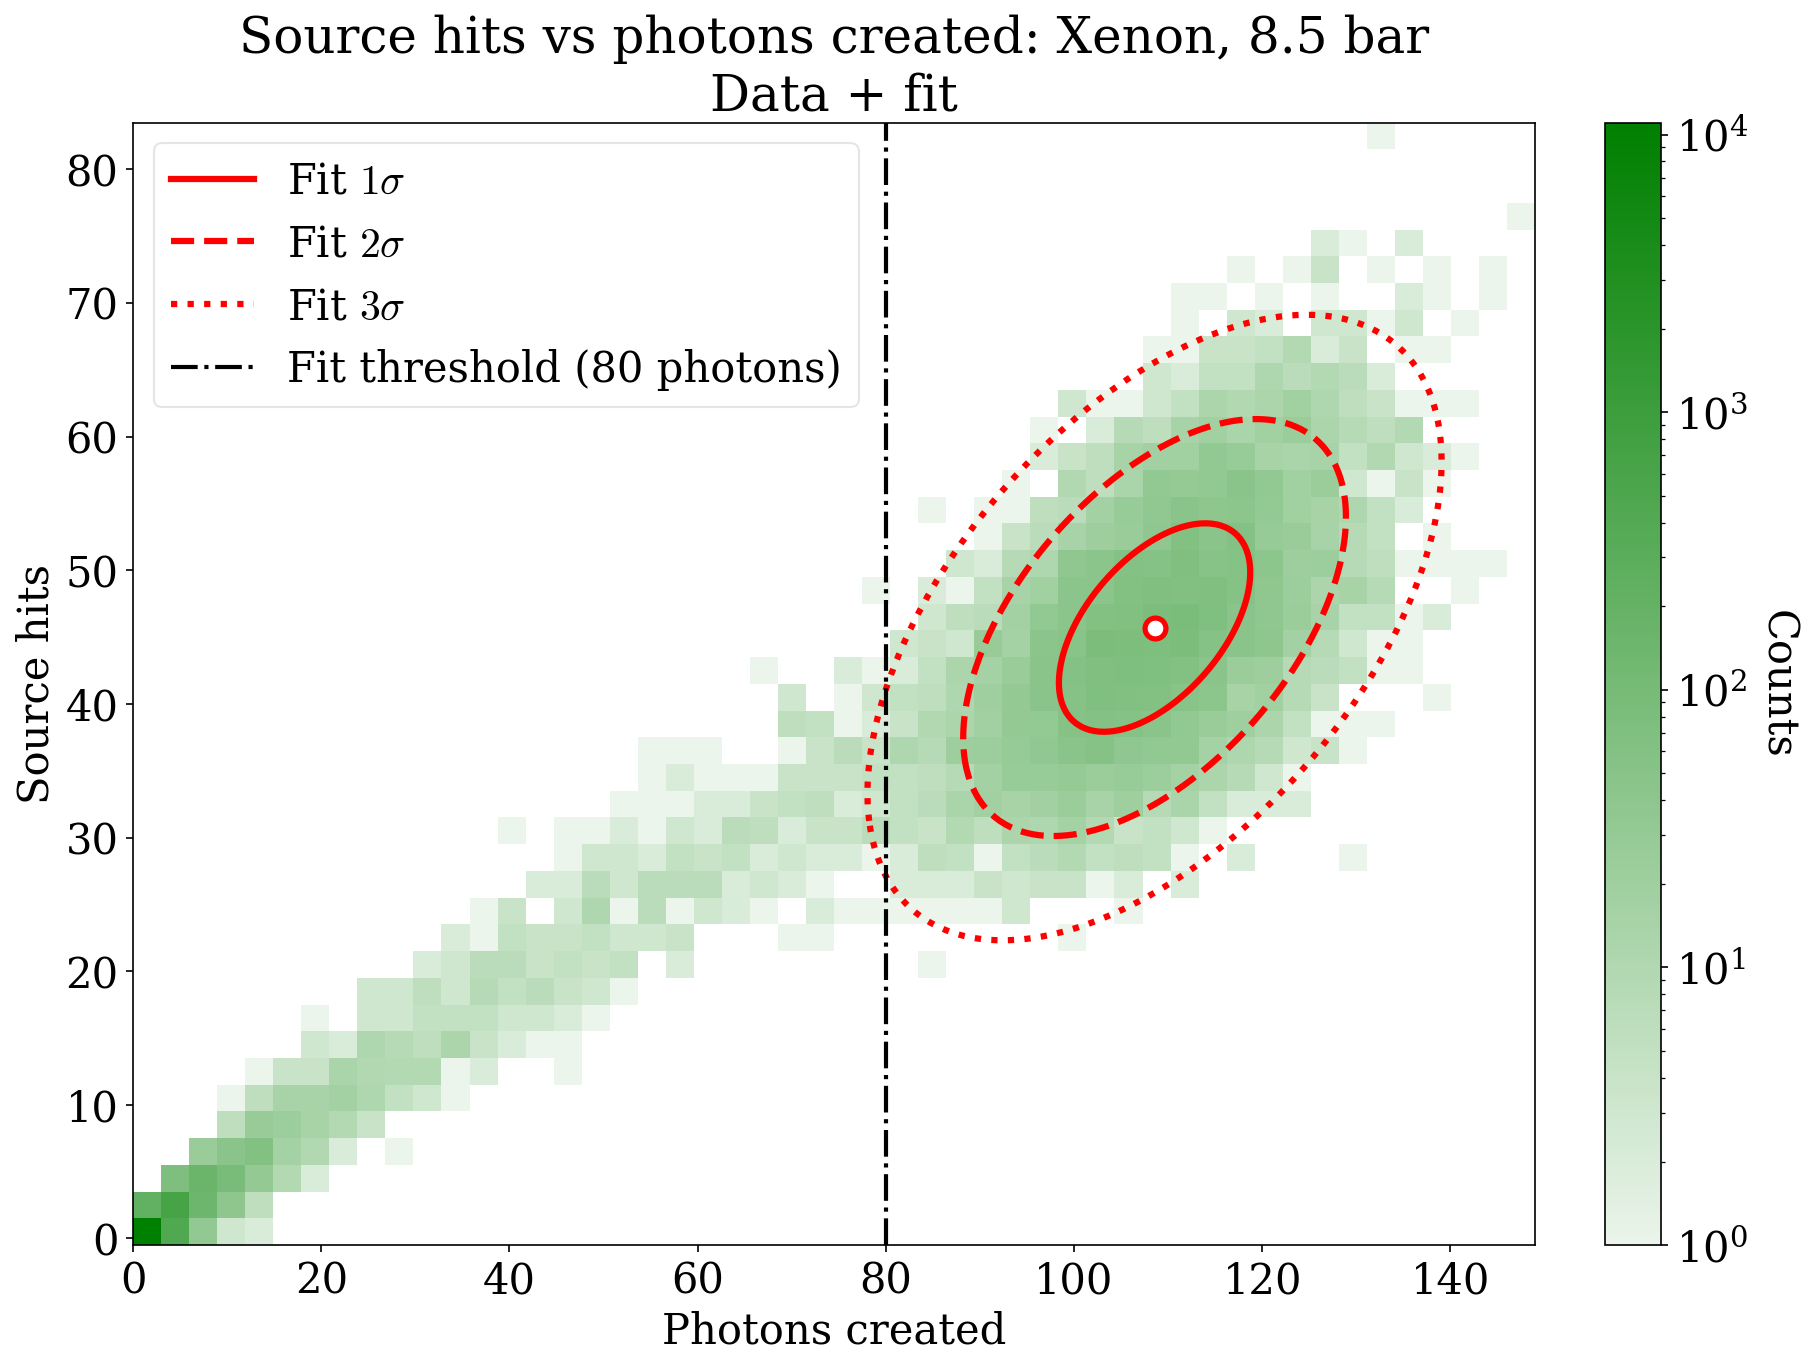

                     A =    81.9896 ± 1.5684
            mu_photons =   108.5596 ± 0.1387
        mu_source_hits =    45.7130 ± 0.1066
         sigma_photons =    10.1668 ± 0.1060
     sigma_source_hits =     7.8003 ± 0.0793
                   rho =     0.5302 ± 0.0101


In [37]:
popt_source, pcov_source = plot_hits_vs_photons(df, 'source_hits', 'Source hits', label, photon_threshold, n_bins_photons)

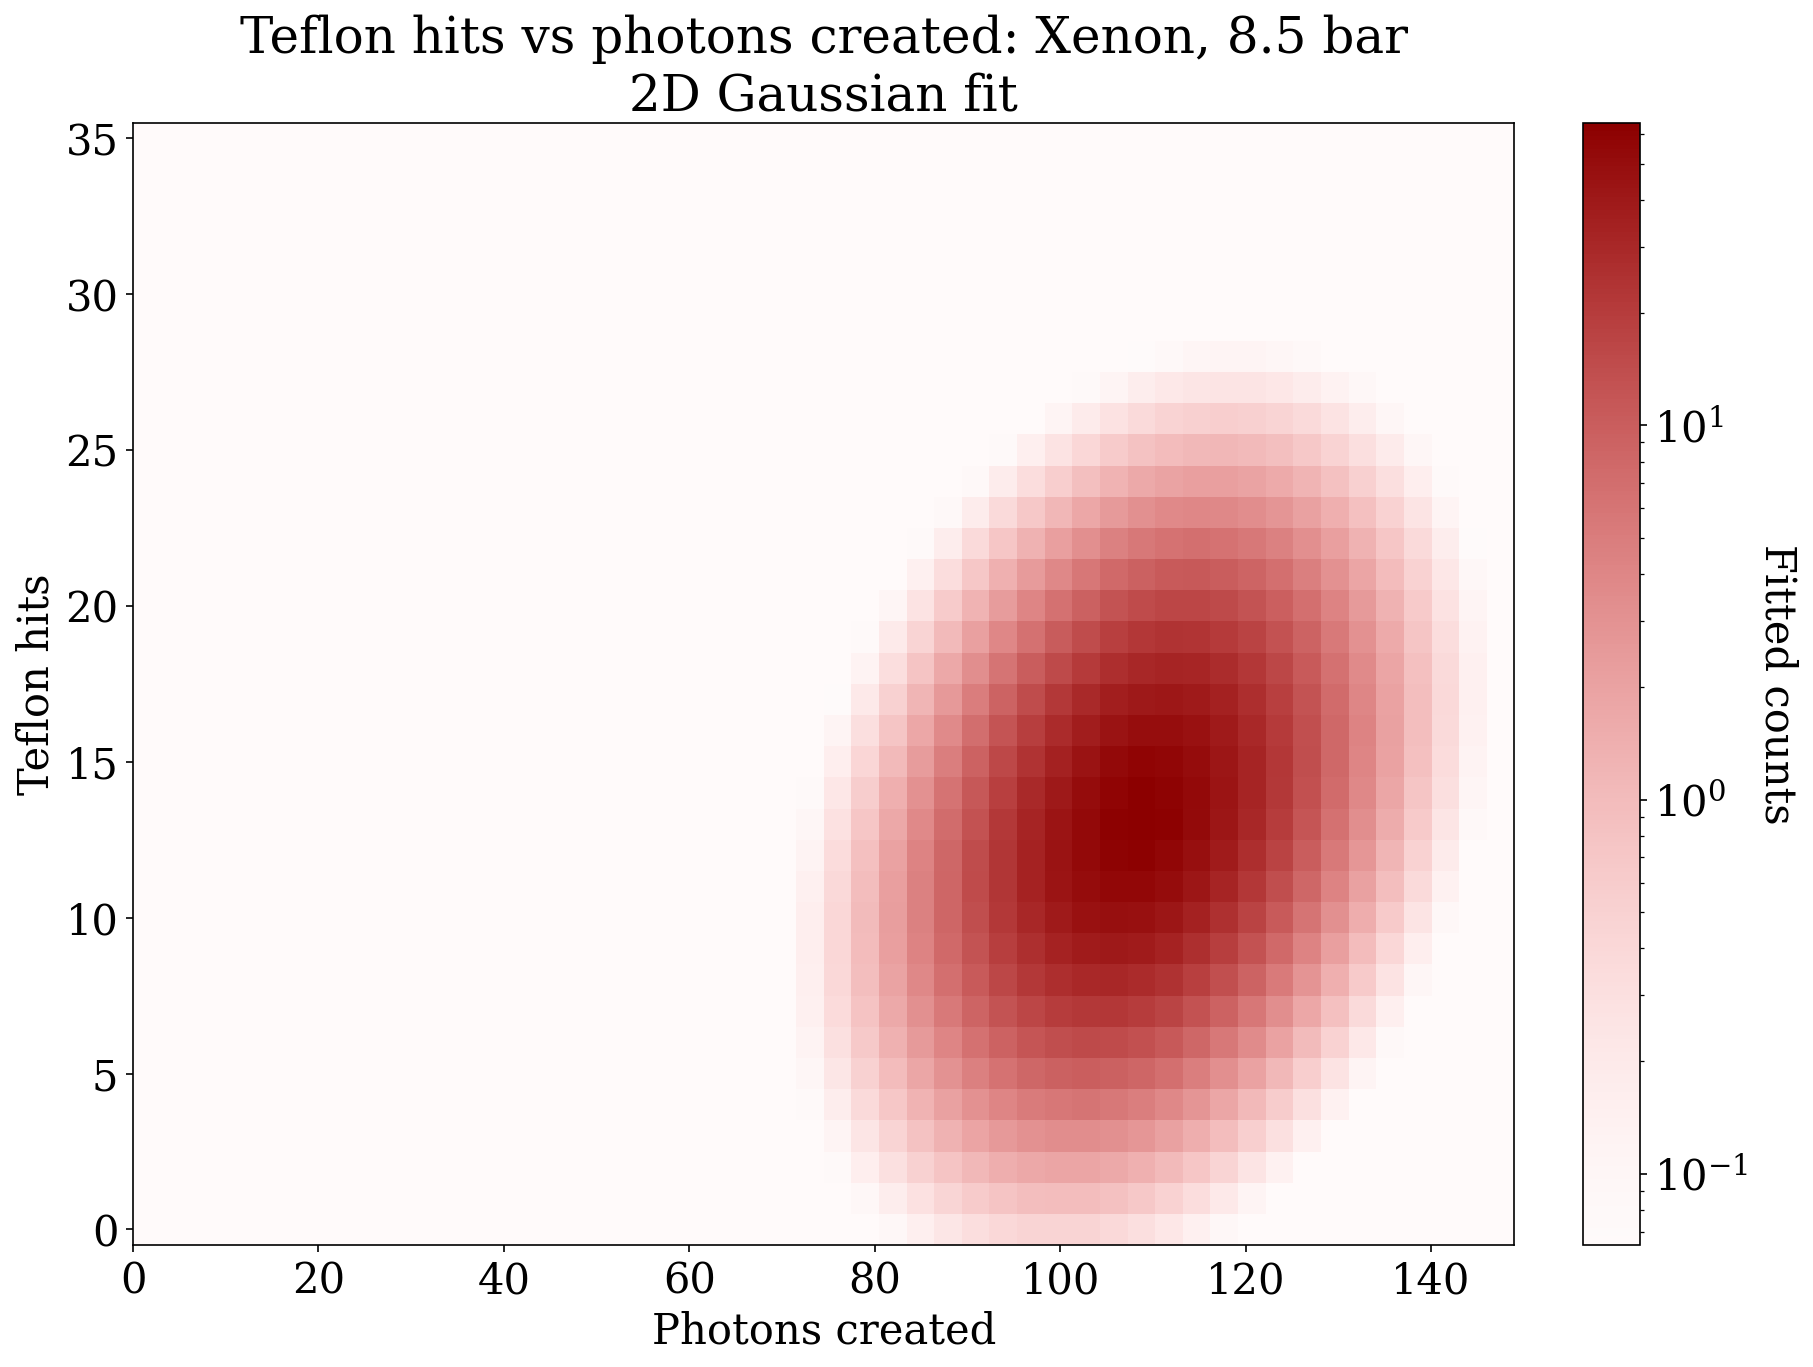

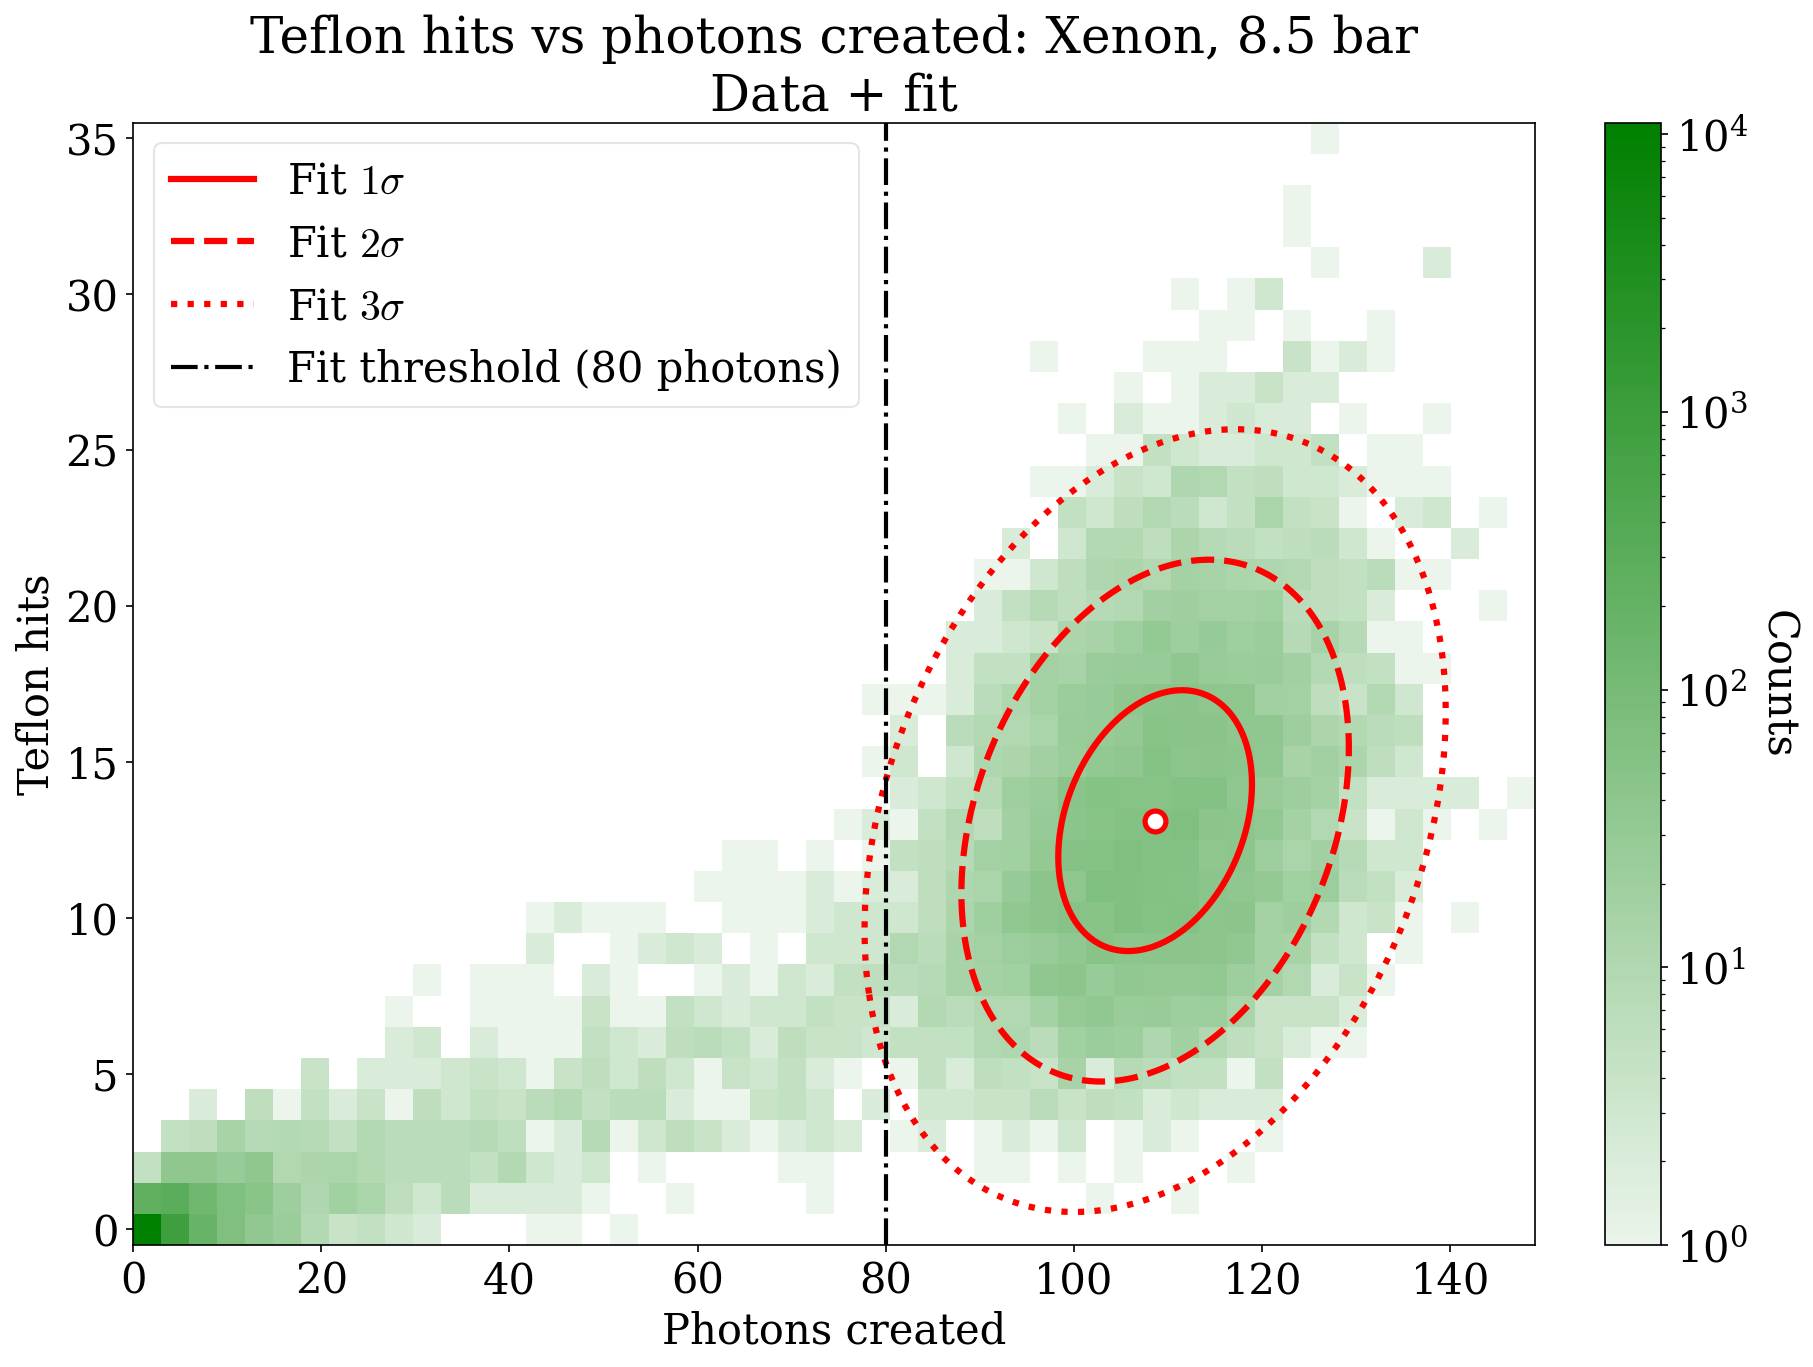

                     A =    64.4545 ± 1.2655
            mu_photons =   108.6194 ± 0.1435
        mu_teflon_hits =    13.1133 ± 0.0589
         sigma_photons =    10.2920 ± 0.1112
     sigma_teflon_hits =     4.1836 ± 0.0430
                   rho =     0.2783 ± 0.0138


In [38]:
popt_teflon, pcov_teflon = plot_hits_vs_photons(df, 'teflon_hits', 'Teflon hits', label, photon_threshold, n_bins_photons)

## Absorption corrections

**From the fit to the fractions.** $\mu_x$ is the mean number of photons created by a full-energy alpha and $\mu_y$ the
mean number of them absorbed by the element, so

$$f = \frac{\mu_y}{\mu_x} = \text{probability that a created photon is absorbed by that element}$$

and the probability that it is **not** absorbed by it is

$$\varepsilon_{\rm teflon} = 1 - \frac{\mu_{\rm teflon}}{\mu_{\rm photons}}, \qquad \varepsilon_{\rm source} = 1 - \frac{\mu_{\rm source}}{\mu_{\rm photons}}$$

Each one comes from its own fit (Teflon Hits vs Photons Created and Source Hits vs Photons Created). The ratio of the
means is used instead of the mean of the per-event ratios, so events with few photons do not get a large weight.

**Combining them.** Each photon ends up in only one place: absorbed in the teflon, absorbed in the source, or
somewhere else (fibers, SiPMs, ...). A photon absorbed in the teflon cannot also be absorbed in the source, so the two
absorbed fractions are exclusive and **add up**:

$$\varepsilon_{\rm tot} = 1 - \frac{\mu_{\rm teflon}}{\mu_{\rm photons}} - \frac{\mu_{\rm source}}{\mu_{\rm photons}} = \varepsilon_{\rm teflon} + \varepsilon_{\rm source} - 1$$

The product $\varepsilon_{\rm teflon} \cdot \varepsilon_{\rm source}$ would be right only if the two fractions were
measured one after the other (e.g. $\varepsilon_{\rm source}$ as a fraction of the photons that already survived the
teflon). Here both are fractions of the same created photons, so the product would add back the
$f_{\rm teflon} \cdot f_{\rm source}$ photons that are counted as absorbed in both and overestimate the survivors
(in Xe at 8.5 bar: 0.51 instead of 0.46).

$\varepsilon_{\rm tot}$ is the `detectable_ratio` used in `EfficiencyVSPressure.ipynb` (stored in `cig.GetEpsTot`).

**Errors.** For each element, the error on $f = \mu_y/\mu_x$ is propagated from the fit covariance, including the
correlation between $\mu_x$ and $\mu_y$:

$$\sigma_f^2 = f^2\left[\frac{\sigma_{\mu_y}^2}{\mu_y^2} + \frac{\sigma_{\mu_x}^2}{\mu_x^2} - \frac{2\,\mathrm{cov}(\mu_x, \mu_y)}{\mu_x \mu_y}\right]$$

and $\sigma_\varepsilon = \sigma_f$. The teflon and source fits are done separately, so for $\varepsilon_{\rm tot}$ their
errors are added in quadrature. These are only the statistical errors of the simulation (~0.1%). The choice of
`photon_threshold` and the optical properties assumed in the simulation (teflon reflectivity, source material, ...)
are systematics that are not included.

In [39]:
def absorbed_fraction(popt, pcov):
    """mu_hits / mu_photons from a 2D Gaussian fit, with its error (including the mu_x - mu_y covariance)."""
    mux, muy = popt[1], popt[2]
    f = muy / mux
    f_err = abs(f) * np.sqrt(pcov[2, 2] / muy**2 + pcov[1, 1] / mux**2 - 2 * pcov[1, 2] / (mux * muy))
    return f, f_err


def absorption_corrections(popt_source, pcov_source, popt_teflon, pcov_teflon):
    f_source, f_source_err = absorbed_fraction(popt_source, pcov_source)
    f_teflon, f_teflon_err = absorbed_fraction(popt_teflon, pcov_teflon)
    return {'eps_source': 1 - f_source, 'eps_source_err': f_source_err,
            'eps_teflon': 1 - f_teflon, 'eps_teflon_err': f_teflon_err,
            # the two fits are done separately, so their errors are added in quadrature
            'eps_tot': 1 - f_source - f_teflon, 'eps_tot_err': np.hypot(f_source_err, f_teflon_err)}


def print_corrections(c, label):
    print(f"{label}:")
    print(f"  eps_source = {c['eps_source']:.4f} ± {c['eps_source_err']:.4f}  (absorbed {100*(1 - c['eps_source']):.2f}%)")
    print(f"  eps_teflon = {c['eps_teflon']:.4f} ± {c['eps_teflon_err']:.4f}  (absorbed {100*(1 - c['eps_teflon']):.2f}%)")
    print(f"  eps_tot    = {c['eps_tot']:.4f} ± {c['eps_tot_err']:.4f}  (photons that survive the absorption)")


corrections = absorption_corrections(popt_source, pcov_source, popt_teflon, pcov_teflon)
print_corrections(corrections, label)

Xenon, 8.5 bar:
  eps_source = 0.5789 ± 0.0008  (absorbed 42.11%)
  eps_teflon = 0.8793 ± 0.0005  (absorbed 12.07%)
  eps_tot    = 0.4582 ± 0.0010  (photons that survive the absorption)


## All pressures

Same fit for every pressure of the selected gas (no plots), with the systematic errors of the optical model on top (next section). The results can be saved for `EfficiencyVSPressure.ipynb` with `write_eps` (see below).

In the plot below, $\varepsilon_{\rm source}$ goes down and $\varepsilon_{\rm teflon}$ goes up with pressure, as
expected from the shorter alpha tracks (see *Why the corrections depend on gas and pressure* above), and
$\varepsilon_{\rm tot}$ decreases because the source term changes faster.

In [40]:
def corrections_for(gas, pressure, threshold):
    df, _ = load_photon_summary(files[(gas, pressure)])
    fits = {}
    for column in ('source_hits', 'teflon_hits'):
        x, y = df['photons_created'].to_numpy(), df[column].to_numpy()
        x_edges, y_edges = hist_edges(x, y, n_bins_photons)
        fits[column] = fit_gaussian_2d(x, y, x_edges, y_edges, threshold)
    return absorption_corrections(*fits['source_hits'], *fits['teflon_hits'])


all_pressures = sorted(p for g, p in files if g == gas)
corrections_vs_p = pd.DataFrame({p: corrections_for(gas, p, photon_threshold) for p in all_pressures}).T
corrections_vs_p.index.name = 'pressure [bar]'
display(corrections_vs_p.round(4))

,eps_source,eps_source_err,eps_teflon,eps_teflon_err,eps_tot,eps_tot_err
pressure [bar],,,,,,
1.0,0.9056,0.0005,0.7062,0.0009,0.6119,0.0010
1.5,0.8668,0.0006,0.6954,0.0008,0.5623,0.0010
2.5,0.7887,0.0008,0.7344,0.0008,0.5231,0.0012
3.5,0.7211,0.0011,0.7831,0.0009,0.5042,0.0014
4.5,0.6686,0.0011,0.8171,0.0008,0.4857,0.0014
5.5,0.6360,0.0010,0.8418,0.0007,0.4778,0.0013
6.5,0.6089,0.0010,0.8594,0.0007,0.4683,0.0012
7.5,0.5957,0.0009,0.8711,0.0006,0.4668,0.0011
8.5,0.5789,0.0008,0.8793,0.0005,0.4582,0.0010


## Systematic errors

The errors above are only statistical. $\varepsilon$ also depends on the optical model of the simulation (reflectivity
of the steel and the PTFE, PTFE surface model, ...), which is not known exactly. `GeometricCorrections_SystError.ipynb`
studies this with simulations that change one optical parameter at a time (`data/MarcFactors/Error_all_pressures_*`);
the same variations and groups are used here:

1. For each variation, $\varepsilon_{\rm teflon}$, $\varepsilon_{\rm source}$ and $\varepsilon_{\rm tot}$ are computed as the ratio of sums over the
   full-energy events (`'mean'` method, see the SystError notebook for why the fit is not used for these small differences),
   and compared with the nominal simulation computed in the same way: shift $= \varepsilon^{\rm variation} - \varepsilon^{\rm nominal}$.
2. Each group (steel reflectivity, UNIFIED model, PTFE reflectivity, PTFE polishing) gives the most negative and the
   most positive shift of its variations.
3. The groups are independent, so they are added in quadrature, separately for each side:
   $\sigma_{\rm syst}^{\pm} = \sqrt{\sum_{\rm groups} (\delta^{\pm}_{\rm group})^2}$.
4. In the plot, the error bars are the total error: statistical and systematic added in quadrature, for each side.

The systematic errors are **asymmetric**: the steel reflectivity variation lets more light survive, so $\varepsilon_{\rm tot}$
can be higher than the nominal (up to ~0.03 at 8.5 bar) but hardly lower. There are no variations at 1.0 bar, so that
point only has its statistical error.


In [41]:
# Same groups as in GeometricCorrections_SystError.ipynb
SYST_GROUPS = {
    'Steel reflectivity': ['STEEL0501'],
    'UNIFIED model'     : ['PTFE_unified'],
    'PTFE reflectivity' : ['PTFE60', 'PTFE85', 'PTFE99', 'PTFE01', 'PTFE05'],
    'PTFE polishing'    : ['PTFE_polished', 'PTFE_polish05'],
}

# Variations: (gas, pressure, tag) -> path
variation_files = {}
for path in glob.glob(os.path.join(data_dir, 'Error_all_pressures_*', '*_error_correct', 'Cigar_*_alpha_*_*.next.h5')):
    m = re.search(r'Cigar_([\d.]+)_alpha_(Ar|Xe)_(\w+)\.next\.h5', os.path.basename(path))
    variation_files[(m.group(2), float(m.group(1)), m.group(3))] = path


def eps_mean(path, threshold):
    '''eps_teflon, eps_source and eps_tot from the ratio of sums over the events with photons >= threshold.'''
    df, _ = load_photon_summary(path)
    sel = df['photons_created'] >= threshold
    n = df.loc[sel, 'photons_created'].sum()
    f_t = df.loc[sel, 'teflon_hits'].sum() / n
    f_s = df.loc[sel, 'source_hits'].sum() / n
    return {'eps_teflon': 1 - f_t, 'eps_source': 1 - f_s, 'eps_tot': 1 - f_t - f_s}


def systematics_for(gas, pressure, threshold):
    '''{key_syst_down, key_syst_up} for key in eps_teflon, eps_source, eps_tot (down <= 0 <= up).'''
    keys = ('eps_teflon', 'eps_source', 'eps_tot')
    tags = {t for g, p, t in variation_files if g == gas and p == pressure}
    if not tags:
        return {f'{k}_syst_{side}': 0. for k in keys for side in ('down', 'up')}

    nominal = eps_mean(files[(gas, pressure)], threshold)
    varied  = {t: eps_mean(variation_files[(gas, pressure, t)], threshold) for t in tags}

    out = {}
    for k in keys:
        down2 = up2 = 0.
        for group_tags in SYST_GROUPS.values():
            shifts = [varied[t][k] - nominal[k] for t in group_tags if t in varied]
            if shifts:
                down2 += min(0, *shifts)**2
                up2   += max(0, *shifts)**2
        out[f'{k}_syst_down'], out[f'{k}_syst_up'] = np.sqrt(down2), np.sqrt(up2)
    return out


syst_vs_p = pd.DataFrame({p: systematics_for(gas, p, photon_threshold) for p in all_pressures}).T
corrections_vs_p = corrections_vs_p.join(syst_vs_p)
display(corrections_vs_p[['eps_tot', 'eps_tot_err', 'eps_tot_syst_down', 'eps_tot_syst_up']].round(4))


,eps_tot,eps_tot_err,eps_tot_syst_down,eps_tot_syst_up
pressure [bar],,,,
1.0,0.6119,0.0010,0.0000,0.0000
1.5,0.5623,0.0010,0.0001,0.0122
2.5,0.5231,0.0012,0.0020,0.0180
3.5,0.5042,0.0014,0.0009,0.0233
4.5,0.4857,0.0014,0.0003,0.0298
5.5,0.4778,0.0013,0.0006,0.0319
6.5,0.4683,0.0012,0.0015,0.0315
7.5,0.4668,0.0011,0.0024,0.0335
8.5,0.4582,0.0010,0.0000,0.0367


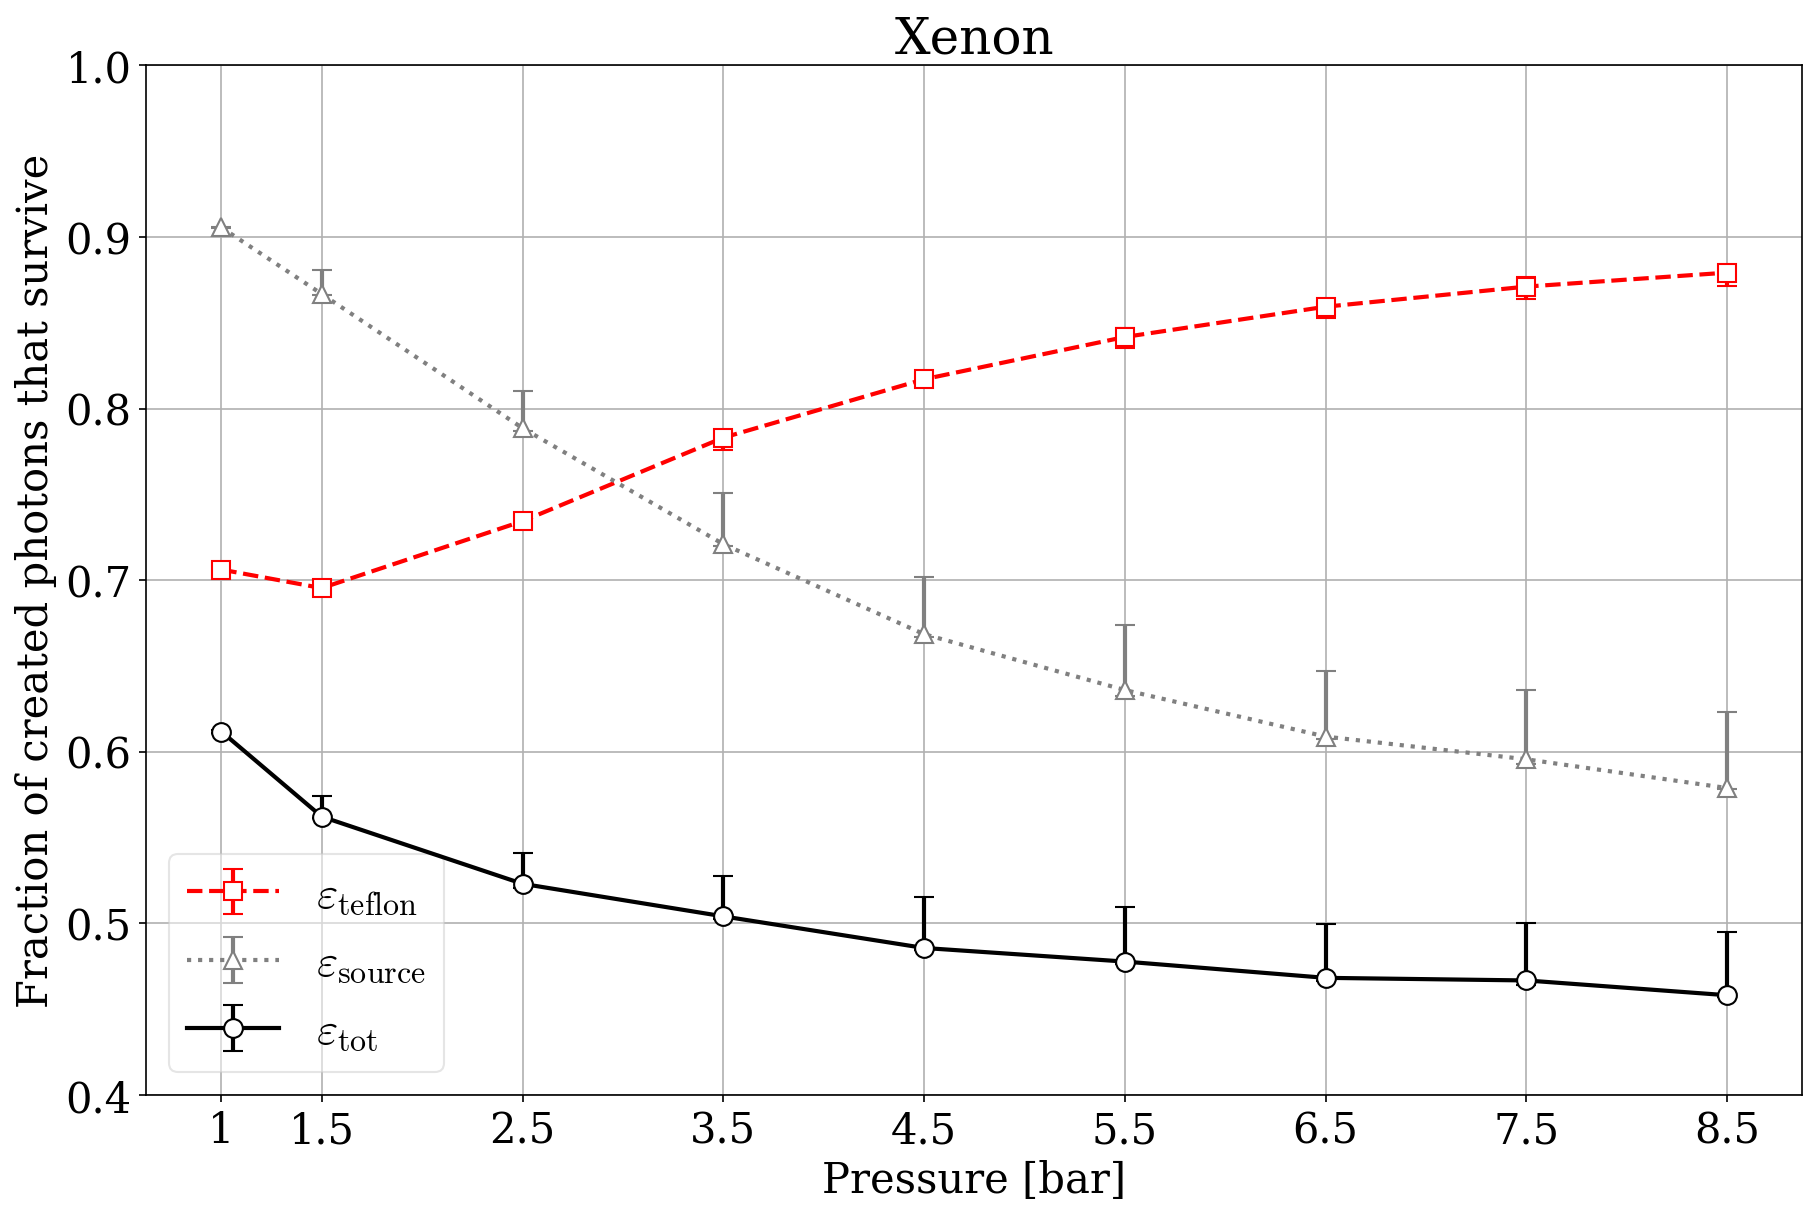

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8), dpi=150, constrained_layout=True)
ax.set_title(GAS_NAMES.get(gas, gas), fontsize=1.2*font_size)

for key, name, color, fmt in [('eps_teflon', r'$\varepsilon_{\rm teflon}$',       'r',    '--s'),
                              ('eps_source', r'$\varepsilon_{\rm source}$',       'grey', ':^'),
                              ('eps_tot',    r'$\varepsilon_{\rm tot}$', 'k',    '-o')]:
    d = corrections_vs_p
    # error bars: total error, stat + syst in quadrature (asymmetric)
    err_down = np.hypot(d[key + '_err'], d[key + '_syst_down'])
    err_up   = np.hypot(d[key + '_err'], d[key + '_syst_up'])
    ax.errorbar(d.index, d[key], yerr=[err_down, err_up],
                fmt=fmt, color=color, markerfacecolor='white', markersize=9, lw=2, capsize=5, zorder=5, label=name)

ax.set_xlabel('Pressure [bar]')
ax.set_ylabel('Fraction of created photons that survive')
ax.set_xticks(corrections_vs_p.index, [f'{p:g}' for p in corrections_vs_p.index])
ax.set_ylim(0.4, 1)
ax.grid(True)
ax.legend(loc='lower left', framealpha=0.5, fontsize=1.1*font_size,
          title_fontsize=0.8*font_size)
plt.show()

## Save $\varepsilon_{\rm tot}$ for the efficiency

With `write_eps = True` (set it in *Choose gas and pressure*), the $\varepsilon_{\rm tot}$ of all the pressures of
the selected gas, with their statistical and systematic errors, are written into `GetEpsTot` in `functions/cigar.py`, replacing the values of that gas.
This works the same way as `WriteDCRPar`/`WriteConvPar`. `EfficiencyVSPressure.ipynb` reads them from there
(`cig.GetEpsTot(gas)`), so after changing the threshold or the simulation, run this notebook once per gas with
`write_eps = True` and re-run the efficiency notebook.

In [43]:
if write_eps:
    cig.WriteEpsTot(corrections_vs_p['eps_tot'].to_dict(), corrections_vs_p['eps_tot_err'].to_dict(), gas, photon_threshold,
                    syst_down=corrections_vs_p['eps_tot_syst_down'].to_dict(), syst_up=corrections_vs_p['eps_tot_syst_up'].to_dict())
    importlib.reload(cig)
    print(cig.GetEpsTot(gas))
else:
    print('write_eps = False: cigar.GetEpsTot not modified')

write_eps = False: cigar.GetEpsTot not modified
